In [9]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import nltk
import re
from collections import Counter

# Sentiment analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import twitter_samples

# Ensure resources are downloaded
nltk.download('twitter_samples')
nltk.download('vader_lexicon')

[nltk_data] Downloading package twitter_samples to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

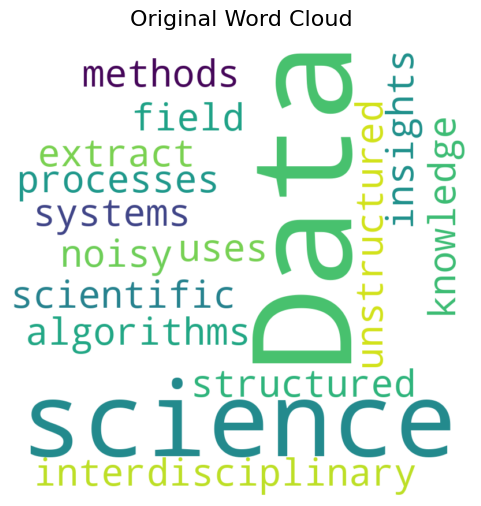

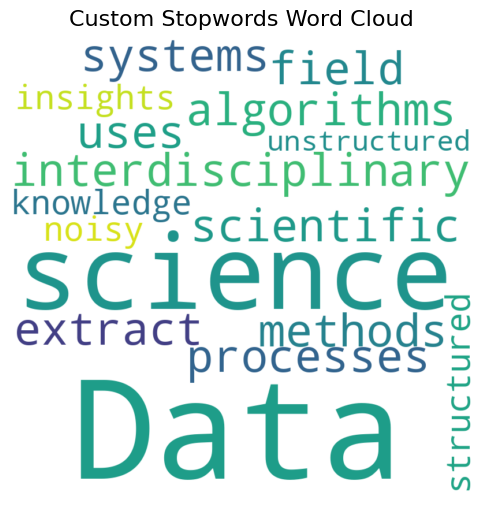

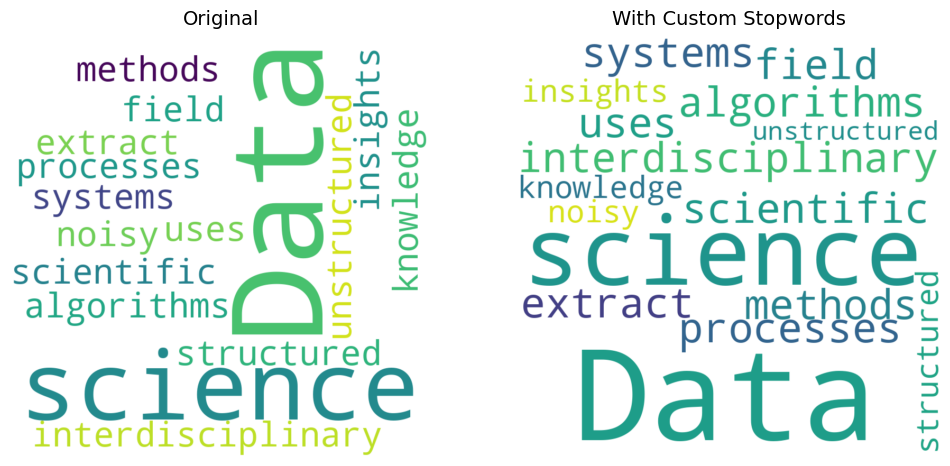

In [10]:
def generate_wordcloud(text, custom_stopwords=None, title="Word Cloud"):
    """
    Generate a word cloud given input text and optional custom stopwords.
    """
    stopwords = STOPWORDS.copy()
    if custom_stopwords:
        stopwords.update(custom_stopwords)
    
    wc = WordCloud(
        width=800, height=800,
        background_color='white',
        stopwords=stopwords,
        min_font_size=10
    ).generate(text)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()
    return wc

# Sample text
sample_text = """
Data science is an interdisciplinary field that uses scientific methods, processes,
algorithms and systems to extract knowledge and insights from noisy, structured and unstructured data.
"""

# Original vs Custom Stop Words
custom_stops = {"said", "using", "would"}
wc_original = generate_wordcloud(sample_text, title="Original Word Cloud")
wc_custom = generate_wordcloud(sample_text, custom_stopwords=custom_stops, title="Custom Stopwords Word Cloud")

# Side by Side Comparison
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(wc_original, interpolation='bilinear')
axs[0].set_title("Original", fontsize=14)
axs[0].axis("off")

axs[1].imshow(wc_custom, interpolation='bilinear')
axs[1].set_title("With Custom Stopwords", fontsize=14)
axs[1].axis("off")

plt.show()


Top Word Frequencies:
data: 2
science: 1
interdisciplinary: 1
field: 1
uses: 1
scientific: 1
methods: 1
processes: 1
algorithms: 1
systems: 1
extract: 1
knowledge: 1
insights: 1
noisy: 1
structured: 1
unstructured: 1


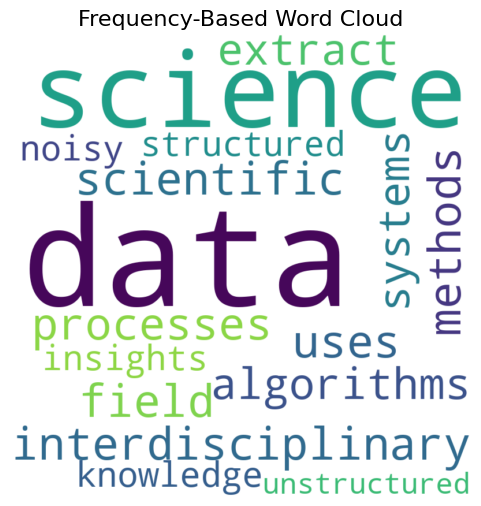

In [11]:
def frequency_based_wordcloud(text, top_n=50):
    """
    Generate a word cloud based on frequency of top N words.
    """
    # Tokenize words
    words = re.findall(r'\b[a-z]{3,}\b', text.lower())  # words with >=3 letters
    stopwords = STOPWORDS
    
    # Filter stop words
    words = [w for w in words if w not in stopwords]
    
    # Count frequencies
    freq = Counter(words).most_common(top_n)
    
    # Print frequency list
    print("Top Word Frequencies:")
    for word, count in freq:
        print(f"{word}: {count}")
    
    # Generate word cloud from frequency dictionary
    wc = WordCloud(
        width=800, height=800,
        background_color='white'
    ).generate_from_frequencies(dict(freq))
    
    plt.figure(figsize=(6, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title("Frequency-Based Word Cloud", fontsize=16)
    plt.show()

# Run example
frequency_based_wordcloud(sample_text, top_n=20)


Sample Tweet: #FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)
Sentiment Score: {'neg': 0.0, 'neu': 0.615, 'pos': 0.385, 'compound': 0.7579}

Top Positive Tweets:
Score=0.987 | There :) is :) a :) pimple :) on :) my :) forehead :) the :) size :) of :) a :) volcano :)
Score=0.980 | A year ago I married my first love and my best friend.  Thanks for an amazing year Glenn!  I love being your wife! :) http://t.co/CbiP1LHLuc
Score=0.980 | Lol :D @akshaykumar i know it was your idea :p coz you have unforgettable sense of humor ;) :) :D love you bro :* https://t.co/qiyrhDK9eB

Top Negative Tweets:
Score=-0.969 | This actually made me cry this is so disgusting whAT THE ACTUAL FUCK im disgusted by what I've seen poor people :( https://t.co/z0iLcKLO6s
Score=-0.962 | :( :( :( when pay day doesn't make you any less poor :( :( :(
Score=-0.958 | That pain from workouts i love but the pain when it impairs me from getting up uggghhhh dam do

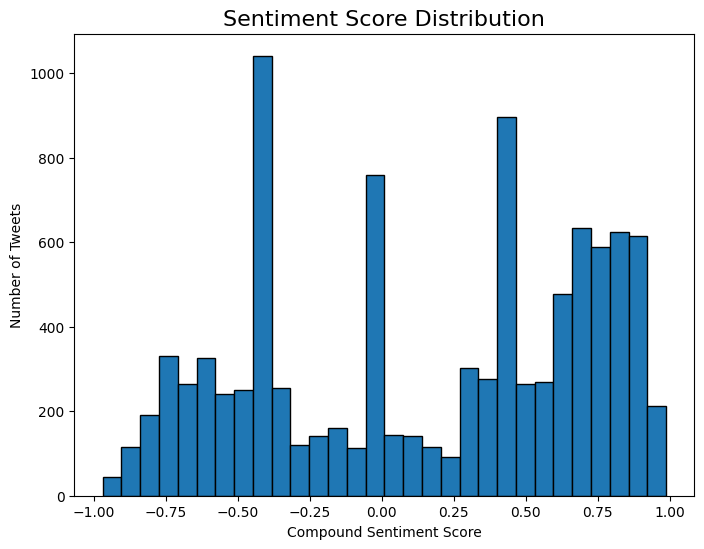

In [12]:
# Initialize analyzer
try:
    sia = SentimentIntensityAnalyzer()
except:
    nltk.download('vader_lexicon')
    sia = SentimentIntensityAnalyzer()

# Load tweets
positive_tweets = twitter_samples.strings('positive_tweets.json')
negative_tweets = twitter_samples.strings('negative_tweets.json')
all_tweets = positive_tweets + negative_tweets

# Analyze a sample tweet
example_tweet = positive_tweets[0]
print("Sample Tweet:", example_tweet)
print("Sentiment Score:", sia.polarity_scores(example_tweet))


# ---- Extreme Sentiment Analysis ----
def analyze_tweets(tweets):
    results = []
    for text in tweets:
        score = sia.polarity_scores(text)
        results.append({
            "text": text,
            "compound": score['compound'],
            "pos": score['pos'],
            "neg": score['neg']
        })
    return results

def extreme_tweets(results, n=3):
    # Sort tweets by compound score
    sorted_pos = sorted(results, key=lambda x: x['compound'], reverse=True)[:n]
    sorted_neg = sorted(results, key=lambda x: x['compound'])[:n]
    
    print("\nTop Positive Tweets:")
    for r in sorted_pos:
        print(f"Score={r['compound']:.3f} | {r['text']}")
    
    print("\nTop Negative Tweets:")
    for r in sorted_neg:
        print(f"Score={r['compound']:.3f} | {r['text']}")

# Analyze all tweets
results = analyze_tweets(all_tweets)

# Show extremes
extreme_tweets(results, n=3)

# ---- Histogram of sentiment distribution ----
scores = [r['compound'] for r in results]
plt.figure(figsize=(8, 6))
plt.hist(scores, bins=30, edgecolor='black')
plt.title("Sentiment Score Distribution", fontsize=16)
plt.xlabel("Compound Sentiment Score")
plt.ylabel("Number of Tweets")
plt.show()
